In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

from src.data import load_dataset


In [2]:
datasets = [
        17,  # Breast Cancer Wisconsin (Diagnostic)
        19,  # Car Evaluation
        43,  # Haberman's Survival
        52,  # Ionosphere
        59,  # Letter Recognition
        78,  # Page Blocks Classification
        94,  # Spambase
        96,  # SPECTF Heart
        151,  # Connectionist Bench (Sonar, Mines vs. Rocks)
        159,  # MAGIC Gamma Telescope
        174,  # Parkinsons
        176,  # Blood Transfusion Service Center
        212,  # Vertebral Column
        267,  # Banknote authentication
        329,  # Diabetic Retinopathy Debrecen
        372,  # HTRU2
        451,  # Breast Cancer Coimbra
        519,  # Heart Failure Clinical Records
        537,  # Cervical Cancer Behavior Risk
        545,  # Rice (Cammeo and Osmancik)
        563,  # Iranian Churn
        572,  # Taiwanese Bankruptcy Prediction
        602,  # Dry Bean
        722,  # NATICUSdroid (Android Permissions)
        827,  # Sepsis Survival Minimal Clinical Records
        850,  # Raisin
        863,  # Maternal health risk
        887,  # National Health and Nutrition Health Survey 2013-2014 (NHANES) Age Prediction Subset
        890,  # AIDS Clinical Trials Group Study 175
        891,  # CDC Diabetes Health Indicators
]

sizes = []
for d_id in datasets:
    X, y = load_dataset(d_id)
    sizes.append((d_id, len(X)))

sizes.sort(key=lambda x: x[1])

for size in sizes:
    print(f"ID {size[0]} (N = {size[1]})")

smallest = sizes[0]
median = sizes[len(sizes) // 2]
largest = sizes[-1]

print(f"Smallest Dataset: ID {smallest[0]} (N = {smallest[1]})")
print(f"Median Dataset:   ID {median[0]} (N = {median[1]})")
print(f"Largest Dataset:  ID {largest[0]} (N = {largest[1]})")

print(len(sizes))

ID 537 (N = 72)
ID 451 (N = 116)
ID 174 (N = 195)
ID 151 (N = 208)
ID 96 (N = 267)
ID 519 (N = 299)
ID 43 (N = 306)
ID 212 (N = 310)
ID 52 (N = 351)
ID 17 (N = 569)
ID 176 (N = 748)
ID 850 (N = 900)
ID 863 (N = 1014)
ID 329 (N = 1151)
ID 267 (N = 1372)
ID 19 (N = 1728)
ID 890 (N = 2139)
ID 887 (N = 2278)
ID 563 (N = 3150)
ID 545 (N = 3810)
ID 94 (N = 4601)
ID 78 (N = 5473)
ID 572 (N = 6819)
ID 602 (N = 13611)
ID 372 (N = 17898)
ID 159 (N = 19020)
ID 59 (N = 20000)
ID 722 (N = 29332)
ID 827 (N = 110341)
ID 891 (N = 253680)
Smallest Dataset: ID 537 (N = 72)
Median Dataset:   ID 19 (N = 1728)
Largest Dataset:  ID 891 (N = 253680)
30


In [3]:
from collections import deque
from sklearn.model_selection import RepeatedStratifiedKFold


def count_calibration_steps(model_function, X_train, y_train, n_splits, n_stop):
    kfold = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=555_555, random_state=0)

    q_len = n_splits * n_stop
    q = deque([1] * q_len, maxlen=q_len)
    all_incorrect_idx = set()
    total_cv_splits = 0
    for data_split_idx, (train_idx, calibration_idx) in enumerate(kfold.split(X_train, y_train)):
        total_cv_splits += 1
        model = model_function()
        model.fit(X_train[train_idx], y_train[train_idx])
        wrong_idx_within_calibration = model.predict(X_train[calibration_idx]) != y_train[calibration_idx]
        wrong_idx_within_training = calibration_idx[wrong_idx_within_calibration]
        n_before = len(all_incorrect_idx)
        all_incorrect_idx.update(wrong_idx_within_training)
        n_new = len(all_incorrect_idx) - n_before
        q.append(n_new)
        # Only evaluate stopping after we complete a full CV set
        # ... can consider changing this later + probably a minor detail, but for now do it this way
        if (data_split_idx + 1) % n_splits == 0 and sum(q) == 0:
            break
        
    return total_cv_splits


In [4]:
X, y = load_dataset(17) # breast cancer wisconsin
le = LabelEncoder()
y = le.fit_transform(y)

In [5]:
X.shape

(569, 30)

In [6]:
from functools import partial
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from src.param_cache import parameter_lookup
params = parameter_lookup(94)
gb_model_fn = partial(DecisionTreeClassifier, random_state=0, **params['decision_tree']['params'])
bb_model_fn = partial(XGBClassifier, random_state=0, **params['xgboost']['params'])
bb_model_fn

functools.partial(<class 'xgboost.sklearn.XGBClassifier'>, random_state=0, max_depth=9, min_child_weight=0.18082838042175542, gamma=0.06923305800973695)

In [7]:
# for i in range(1, 6):
#     n_steps = count_calibration_steps(model_function=bb_model_fn, X_train=X, y_train=y, n_splits=5, n_stop=i)
#     print(f'i: {i}, n_steps: {n_steps}')

In [8]:
# n_steps_one_pass = []
# one_pass_basket = datasets
# 
# for dataset_id in one_pass_basket:
#     print(f'dataset_id: {dataset_id}')
#     X, y = load_dataset(dataset_id)
#     le = LabelEncoder()
#     y = le.fit_transform(y)
#     
#     params = parameter_lookup(dataset_id)
#     
#     gb_model_fn = partial(DecisionTreeClassifier, random_state=0, **params['decision_tree']['params'])
#     bb_model_fn = partial(XGBClassifier, random_state=0, **params['xgboost']['params'])
#     
#     n_steps_glass = count_calibration_steps(gb_model_fn, X_train=X, y_train=y, n_splits=5, n_stop=1)
#     n_steps_black = count_calibration_steps(bb_model_fn, X_train=X, y_train=y, n_splits=5, n_stop=1)
#     
#     n_steps_one_pass.append({
#         'dataset_id': dataset_id,
#         'n_steps_glass': n_steps_glass,
#         'n_steps_black': n_steps_black,
#     })
#     
# n_steps_one_pass

In [9]:
# n_steps_many_passes = []
# many_pass_basket = [329, 267, 19, 890, 887]
# for dataset_id in many_pass_basket:
#     print(f'dataset_id: {dataset_id}')
#     X, y = load_dataset(dataset_id)
#     le = LabelEncoder()
#     y = le.fit_transform(y)
#     
#     params = parameter_lookup(dataset_id)
#     
#     gb_model_fn = partial(DecisionTreeClassifier, random_state=0, **params['decision_tree']['params'])
#     bb_model_fn = partial(XGBClassifier, random_state=0, **params['xgboost']['params'])
#     
#     for n_passes in range(1, 11):
#         print(f'  n_passes: {n_passes}')
#         n_steps_glass = count_calibration_steps(gb_model_fn, X_train=X, y_train=y, n_splits=5, n_stop=n_passes)
#         n_steps_black = count_calibration_steps(bb_model_fn, X_train=X, y_train=y, n_splits=5, n_stop=n_passes)
#         n_steps_many_passes.append({
#             'dataset_id': dataset_id,
#             'n_passes': n_passes,
#             'n_steps_glass': n_steps_glass,
#             'n_steps_black': n_steps_black,
#         })
#         
# n_steps_many_passes

In [10]:
# from sklearn.model_selection import RepeatedStratifiedKFold
# 
# def count_calibration_steps_optimized(model_function, X_train, y_train, n_splits, max_stop):
#     kfold = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=555_555, random_state=0)
# 
#     all_incorrect_idx = set()
#     total_cv_splits = 0
#     
#     consecutive_stable_passes = 0
#     new_in_current_pass = 0
#     
#     # results[i] will store the splits needed to reach (i + 1) stable passes
#     results = [None] * max_stop
#     
#     for data_split_idx, (train_idx, calibration_idx) in enumerate(kfold.split(X_train, y_train)):
#         total_cv_splits += 1
#         model = model_function()
#         model.fit(X_train[train_idx], y_train[train_idx])
#         
#         wrong_idx_within_calibration = model.predict(X_train[calibration_idx]) != y_train[calibration_idx]
#         wrong_idx_within_training = calibration_idx[wrong_idx_within_calibration]
#         
#         n_before = len(all_incorrect_idx)
#         all_incorrect_idx.update(wrong_idx_within_training)
#         n_new = len(all_incorrect_idx) - n_before
#         
#         new_in_current_pass += n_new
#         
#         # Evaluate only at the end of a full CV pass (e.g., every 5 splits)
#         if total_cv_splits % n_splits == 0:
#             if new_in_current_pass == 0:
#                 consecutive_stable_passes += 1
#             else:
#                 consecutive_stable_passes = 0
#             
#             # Check if we just crossed any new stability thresholds
#             for i in range(1, max_stop + 1):
#                 # If we achieved 'i' stable passes and haven't recorded it yet
#                 if consecutive_stable_passes >= i and results[i-1] is None:
#                     results[i-1] = total_cv_splits
#             
#             # Reset the counter for the next CV pass
#             new_in_current_pass = 0
#             
#             # If the array is fully populated, we've found all stopping conditions!
#             if all(r is not None for r in results):
#                 break
#                 
#     return results

In [11]:
# n_steps_many_passes_full = []
# many_pass_basket_full = [94, 545, 563,
#                     887, 890, 19,
#                     267, 329, 863,
#                     850, 176, 17,
#                     52, 212, 43,
#                     519, 96, 151,
#                     174, 451, 537,
# ]
# 
# for dataset_id in many_pass_basket_full:
#     print(f'dataset_id: {dataset_id}')
#     X, y = load_dataset(dataset_id)
#     le = LabelEncoder()
#     y = le.fit_transform(y)
#     
#     params = parameter_lookup(dataset_id)
#     
#     gb_model_fn = partial(DecisionTreeClassifier, random_state=0, **params['decision_tree']['params'])
#     bb_model_fn = partial(XGBClassifier, random_state=0, **params['xgboost']['params'])
#     
#     glass_results = count_calibration_steps_optimized(gb_model_fn, X_train=X, y_train=y, n_splits=5, max_stop=10)
#     black_results = count_calibration_steps_optimized(bb_model_fn, X_train=X, y_train=y, n_splits=5, max_stop=10)
#     
#     for i in range(10):
#         n_passes = i + 1
#         n_steps_many_passes_full.append({
#             'dataset_id': dataset_id,
#             'n_passes': n_passes,
#             'n_steps_glass': glass_results[i],
#             'n_steps_black': black_results[i],
#         })
#         
# many_pass_basket_full

In [12]:
# n_steps_many_passes_full

In [13]:
import ast
import numpy as np
with open('n_steps_many_passes_full.json', 'r', encoding='utf-8') as f:
    results = ast.literal_eval(f.read())
results

[{'dataset_id': 94, 'n_passes': 1, 'n_steps_glass': 185, 'n_steps_black': 130},
 {'dataset_id': 94, 'n_passes': 2, 'n_steps_glass': 315, 'n_steps_black': 295},
 {'dataset_id': 94, 'n_passes': 3, 'n_steps_glass': 445, 'n_steps_black': 420},
 {'dataset_id': 94, 'n_passes': 4, 'n_steps_glass': 520, 'n_steps_black': 645},
 {'dataset_id': 94, 'n_passes': 5, 'n_steps_glass': 550, 'n_steps_black': 650},
 {'dataset_id': 94, 'n_passes': 6, 'n_steps_glass': 555, 'n_steps_black': 655},
 {'dataset_id': 94, 'n_passes': 7, 'n_steps_glass': 560, 'n_steps_black': 660},
 {'dataset_id': 94, 'n_passes': 8, 'n_steps_glass': 565, 'n_steps_black': 905},
 {'dataset_id': 94, 'n_passes': 9, 'n_steps_glass': 620, 'n_steps_black': 960},
 {'dataset_id': 94,
  'n_passes': 10,
  'n_steps_glass': 625,
  'n_steps_black': 965},
 {'dataset_id': 545, 'n_passes': 1, 'n_steps_glass': 35, 'n_steps_black': 50},
 {'dataset_id': 545, 'n_passes': 2, 'n_steps_glass': 60, 'n_steps_black': 145},
 {'dataset_id': 545, 'n_passes': 3

## n_passes versus n_steps

In [14]:
n_steps_per_pass_glass = [[] for _ in range(10)]
n_steps_per_pass_black = [[] for _ in range(10)]
for result in results:
    n_passes, n_steps_glass, n_steps_black = result['n_passes'], result['n_steps_glass'], result['n_steps_black']
    n_steps_per_pass_glass[n_passes - 1].append(result['n_steps_glass'])
    n_steps_per_pass_black[n_passes - 1].append(result['n_steps_black'])
average_steps_per_pass_glass = np.array(n_steps_per_pass_glass).mean(axis=1)
average_steps_per_pass_black = np.array(n_steps_per_pass_black).mean(axis=1)
average_steps_per_pass_glass

array([ 47.38095238, 100.47619048, 130.47619048, 146.66666667,
       171.9047619 , 194.52380952, 203.57142857, 225.        ,
       268.57142857, 292.85714286])

In [15]:
import numpy as np
from scipy.stats import linregress


# x is your passes (1 through 10), y is your array
x = np.arange(1, 11)
slope, intercept, r_value, p_value, std_err = linregress(x, average_steps_per_pass_glass)

print(f"R-squared: {r_value**2:.4f}")
print(f"Slope: {slope:.1f} steps per additional pass")

R-squared: 0.9778
Slope: 24.6 steps per additional pass


In [16]:
average_steps_per_pass_black

array([ 59.28571429, 109.76190476, 151.66666667, 181.19047619,
       229.28571429, 267.14285714, 334.52380952, 377.61904762,
       403.80952381, 478.57142857])

In [17]:
import numpy as np
from scipy.stats import linregress


# x is your passes (1 through 10), y is your array
x = np.arange(1, 11)
slope, intercept, r_value, p_value, std_err = linregress(x, average_steps_per_pass_black)

print(f"R-squared: {r_value**2:.4f}")
print(f"Slope: {slope:.1f} steps per additional pass")

R-squared: 0.9940
Slope: 45.2 steps per additional pass


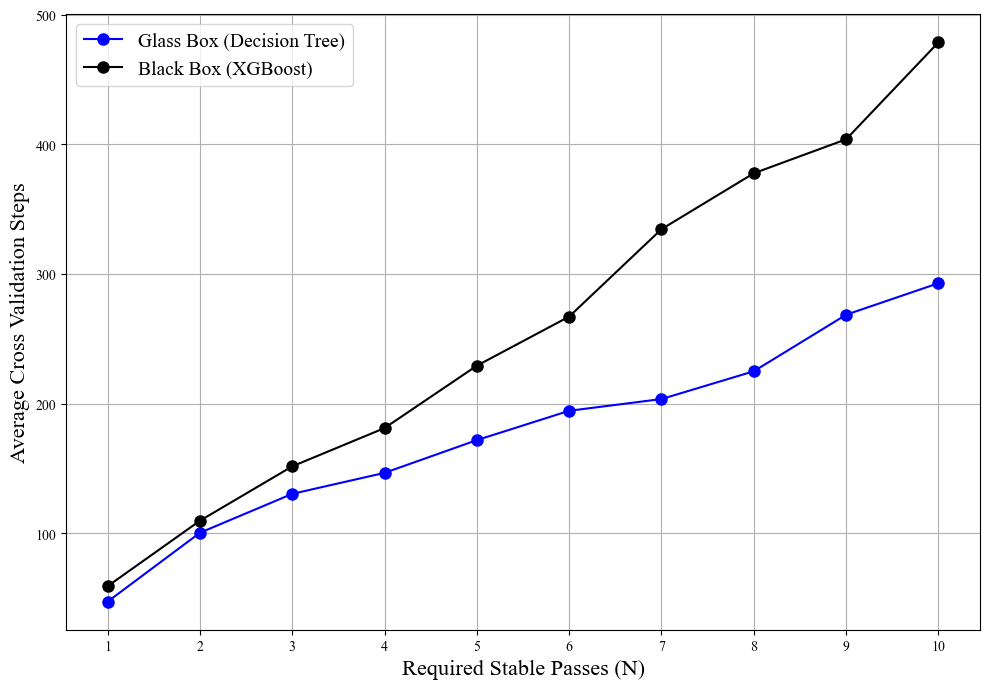

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Match your previous plot's font
rcParams['font.family'] = 'Times New Roman'

x = np.arange(1, 11)
plt.figure(figsize=(10, 7))

plt.plot(x, average_steps_per_pass_glass, 'o-', color='blue', markersize=8, label='Glass Box (Decision Tree)')
plt.plot(x, average_steps_per_pass_black, 'o-', color='black', markersize=8, label='Black Box (XGBoost)')

plt.xlabel("Required Stable Passes (N)", fontsize=16)
plt.ylabel("Average Cross Validation Steps", fontsize=16)
plt.xticks(np.arange(1, 11, step=1))
plt.grid()
plt.legend(fontsize=14, loc='upper left')

# Adjust layout and save
plt.tight_layout()
plt.savefig('figv2/out/complexity_vs_stable_passes.pdf', bbox_inches='tight', transparent=True)
plt.show()

## n_steps versus dataset size

In [38]:
target_n_passes = 1
sizes_dict = {}
for size in sizes:
    sizes_dict[size[0]] = size[1]

n_steps_by_size_glass = []
n_steps_by_size_black = []

for result in results:
    n_passes, n_steps_glass, n_steps_black = result['n_passes'], result['n_steps_glass'], result['n_steps_black']
    size = sizes_dict[result['dataset_id']]
    if n_passes == target_n_passes:
        n_steps_by_size_glass.append((size, result['n_steps_glass']))
        n_steps_by_size_black.append((size, result['n_steps_black']))
        
n_steps_by_size_glass = np.array(n_steps_by_size_glass)
n_steps_by_size_black = np.array(n_steps_by_size_black)
n_steps_by_size_glass

array([[4601,  185],
       [3810,   35],
       [3150,   50],
       [2278,   10],
       [2139,   25],
       [1728,   15],
       [1372,   75],
       [1151,  105],
       [1014,   70],
       [ 900,   35],
       [ 748,   40],
       [ 569,   55],
       [ 351,   10],
       [ 310,   50],
       [ 306,   45],
       [ 299,   10],
       [ 267,   10],
       [ 208,   35],
       [ 195,   75],
       [ 116,   35],
       [  72,   25]])

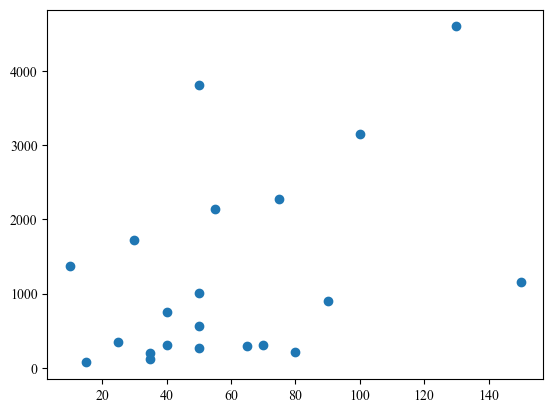

In [39]:
from matplotlib import pyplot as plt
plt.scatter(n_steps_by_size_black[:, 1], n_steps_by_size_black[:, 0])

Glass Box: 0.014415028571114553 + 29.819329001743107, R2: 0.2142213342186009
Black Box: 0.01210212054256658 + 44.541873716141744, R2: 0.19454797788678663


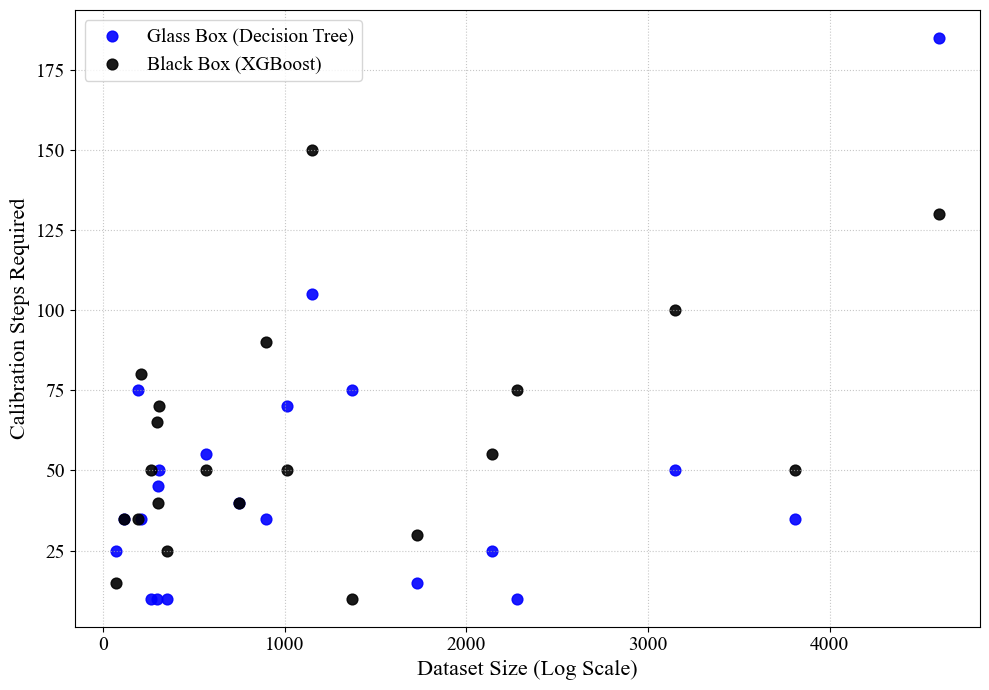

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'

glass_steps, black_steps = n_steps_by_size_glass[:, 1], n_steps_by_size_black[:, 1]
ds_sizes = n_steps_by_size_glass[:, 0]
log_sizes = np.log(ds_sizes)

glass_slope, glass_int, glass_r, _, _ = linregress(ds_sizes, glass_steps)
black_slope, black_int, black_r, _, _ = linregress(ds_sizes, black_steps)

print(f"Glass Box: {glass_slope} + {glass_int}, R2: {glass_r**2}")
print(f"Black Box: {black_slope} + {black_int}, R2: {black_r**2}")

plt.figure(figsize=(10, 7))
#plt.xscale('log')

# Plot raw scatter points
plt.scatter(ds_sizes, glass_steps, color='blue', s=60, alpha=0.9, label='Glass Box (Decision Tree)')
plt.scatter(ds_sizes, black_steps, color='black', s=60, alpha=0.9, label='Black Box (XGBoost)')

# trend_x = np.linspace(min(ds_sizes), max(ds_sizes), 500)
# glass_trend_y = glass_slope * np.log(trend_x) + glass_int
# black_trend_y = black_slope * np.log(trend_x) + black_int
# plt.plot(trend_x, glass_trend_y, '--', color='blue', linewidth=2)
# plt.plot(trend_x, black_trend_y, '--', color='black', linewidth=2)


plt.xlabel("Dataset Size (Log Scale)", fontsize=16)
plt.ylabel("Calibration Steps Required", fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=14, loc='upper left')

plt.tight_layout()
plt.savefig('figv2/out/complexity_vs_size.pdf', bbox_inches='tight', transparent=True)
plt.show()

In [33]:
ds_sizes

array([4601, 3810, 3150, 2278, 2139, 1728, 1372, 1151, 1014,  900,  748,
        569,  351,  310,  306,  299,  267,  208,  195,  116,   72])